In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive/Colab')

['placement_dataset.csv',
 'placement_predict_50k Dataset (1) (1).csv',
 'placement_predict_50k_adjusted.csv',
 'age_insurance.csv',
 'simple_placement_dataset.csv',
 'movies_dataset(1).csv',
 'WineQT.csv',
 'WineQT_Feature_Engineered.csv',
 'placement_predict_50k_adjusted (1).csv',
 'student_data.csv',
 'xgboost_lightgbm_shap_student_dataset.csv']

In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/placement_dataset.csv')

===== XGBoost ===telek
Accuracy: 0.9
              precision    recall  f1-score   support

           0       0.94      0.85      0.89        20
           1       0.86      0.95      0.90        20

    accuracy                           0.90        40
   macro avg       0.90      0.90      0.90        40
weighted avg       0.90      0.90      0.90        40

===== LightGBM ===telek
Accuracy: 0.925
              precision    recall  f1-score   support

           0       0.95      0.90      0.92        20
           1       0.90      0.95      0.93        20

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.92        40



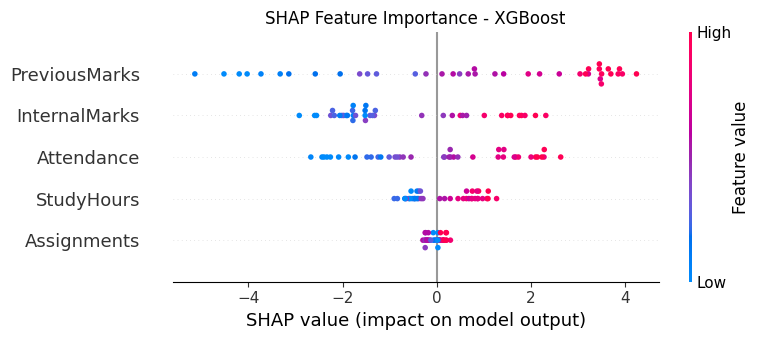

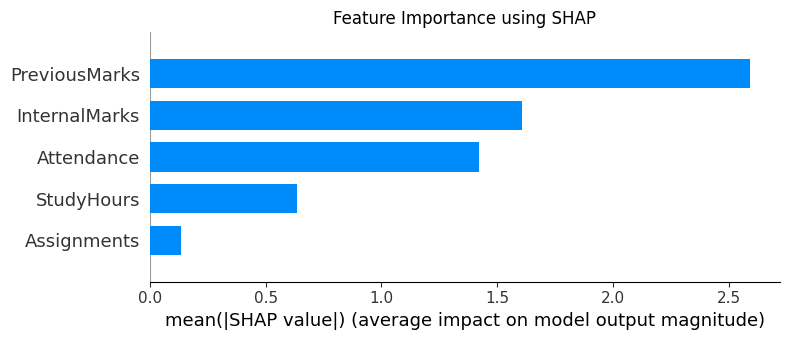


Sample Data:
     StudyHours  Attendance  Assignments  PreviousMarks  InternalMarks
177           2          50            4             91             42
Prediction: FAIL


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# 1. Load dataset
data = pd.read_csv("/content/drive/MyDrive/Colab/xgboost_lightgbm_shap_student_dataset.csv")

# 2. Separate features and target
X = data.drop("Result", axis=1)
y = data["Result"]

# 3. Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================
# XGBoost Model
# =========================

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("===== XGBoost ===telek")
print("Accuracy:",
      accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))


# =========================
# LightGBM Model
# =========================

lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    verbosity=-1
)

lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_test)

print("===== LightGBM ===telek")
print("Accuracy:",
      accuracy_score(y_test, lgb_pred))
print(classification_report(y_test, lgb_pred))


# =========================
# SHAP Interpretability
# =========================

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Feature Importance - XGBoost")
plt.tight_layout()
plt.show()


# SHAP Bar Plot
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.title("Feature Importance using SHAP")
plt.tight_layout()
plt.show()


# =========================
# Individual Prediction
# =========================

sample = X_test.iloc[[0]]

prediction = xgb_model.predict(sample)

print("\nSample Data:")
print(sample)

if prediction[0] == 1:
    print("Prediction: PASS")
else:
    print("Prediction: FAIL")